# 🎵 Clasificación de Géneros Musicales — Deep Learning - V4
## Arquitectura: CNN (EfficientNet-B0) + BiLSTM + Attention Pooling

---

### Diagnóstico del overfitting (train F1 ~0.9 vs val F1 ~0.5)

El gap train/val tenía 4 causas identificadas:

| # | Causa | Efecto | Solución |
|---|---|---|---|
| 1 | **WeightedRandomSampler muy agresivo** | Las 56 muestras de clase 0 se repiten ~95x por epoch → memorización | Sampler con temperatura √ + cap a 3x la clase mayoritaria |
| 2 | **Backbone nunca congelado al inicio** | La cabeza (LSTM+head) se entrena sobre features inestables de ImageNet → diverge | Freeze 5 épocas → Unfreeze gradual con lr×0.01 |
| 3 | **Train F1 sesgado por Mixup** | Solo se contaban batches sin mixup (~50%) → F1 artificialmente alto | Siempre computar argmax sobre logits aunque haya mixup |
| 4 | **SpecAugment demasiado agresivo** | Val ve espectrogramas limpios, train vio hasta 36% de frecuencias ocultas | Reducir: freq_mask 24→16, time_mask 64→48, num_time_masks 2→1 |

### Cambios en esta versión (v4)
- **Freeze/Unfreeze**: épocas 1-5 solo entrena cabeza, épocas 6+ desbloquea backbone con lr muy bajo
- **Sampler suavizado**: pesos ∝ 1/√count con cap, evita que clase 0 domine el batch
- **Train F1 honesto**: se calcula sobre todos los batches (con y sin mixup)
- **SpecAugment moderado**: menos distorsión → menor brecha train/val
- **drop_path_rate=0.1** en EfficientNet: regularización por Stochastic Depth

## 1. Instalación y configuración

In [2]:
!pip install -q librosa audiomentations timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 11.8 MB/s eta 0:00:00


In [3]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter

# Audio
import librosa
import soundfile as sf
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR
from torch.cuda.amp import GradScaler, autocast

# Vision backbone
import timm

# Métricas
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')

# =================================================================
# CONFIGURACIÓN GLOBAL
# =================================================================
# Decisión: centralizar todo para facilitar experimentación.
# Cambios clave vs notebook anterior:
#   - EfficientNet-B0 en vez de B2 (menos parámetros)
#   - Sin Transformer (reemplazado por BiLSTM + Attention)
#   - Batch size 32 (sin gradient accumulation, más estable)
#   - Focal Loss con class weights
#   - OneCycleLR (converge más rápido que CosineAnnealing)

CFG = {
    # Paths
    'path': '/kaggle/input/datasets/jeffreyamc/music-genres-lab/',
    
    # Audio
    'sample_rate': 22050,
    'duration': 20,         # 20 segundos por clip
    'n_mels': 128,          # Bandas mel: 128 es estándar, buena resolución frecuencial
    'n_fft': 2048,          # Ventana FFT: 2048 samples (~93ms a 22050Hz)
    'hop_length': 512,      # Hop: 512 (~23ms) → buena resolución temporal
    'fmin': 20,             # Frecuencia mínima audible
    'fmax': 8000,           # Frecuencia máxima (suficiente para música)
    
    # Caché de espectrogramas (acelera 10-20x el entrenamiento)
    'cache_dir': '/kaggle/working/mel_cache',
    
    # Modelo
    'backbone': 'tf_efficientnet_b0_ns',  # B0 en vez de B2: menos overfitting
    'n_classes': 15,
    'dropout': 0.4,         # Más agresivo que antes (0.3)
    'lstm_hidden': 256,     # Dimensión BiLSTM
    'lstm_layers': 1,       # 1 sola capa: suficiente para secuencias cortas
    
    # Entrenamiento
    'epochs': 40,
    'freeze_epochs': 5,    # Épocas con backbone congelado antes de descongelar
    'batch_size': 32,       # Sin accumulation: más estable
    'lr': 1e-3,             # OneCycleLR empieza bajo, sube, y baja
    'weight_decay': 1e-3,   # Más regularización L2
    'label_smoothing': 0.1,
    'focal_gamma': 2.0,     # Focal Loss gamma: penaliza ejemplos fáciles
    'mixup_alpha': 0.3,     # Mixup: interpolación de muestras
    'use_mixup': True,
    
    # SpecAugment — decisión: más agresivo que antes
    'freq_mask_param': 16,  # Reducido: 24→16 para no sobre-distorsionar
    'time_mask_param': 48,  # Reducido: 64→48rales
    'num_freq_masks': 2,
    'num_time_masks': 1,   # Reducido: 2→1 para moderar SpecAugment
    
    # Cross-validation
    'n_folds': 5,
    'fold': 0,
    
    # Hardware
    'seed': 42,
    'num_workers': 4,
    'pin_memory': True,
    'fp16': True,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Carga y exploración de datos

In [4]:
path = CFG['path']
print(f'Contenido del directorio: {os.listdir(path)}')

# Cargar CSV de labels
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
print(f'\nTrain: {len(train_df)} muestras')

# Rutas de audio
train_audio_path = os.path.join(path, 'train/train')
test_audio_path = os.path.join(path, 'test/test')

train_df['filepath'] = train_df['Id'].apply(lambda x: os.path.join(train_audio_path, f'{x}.wav'))

# Test: construir desde los archivos en disco
test_files = sorted([f.replace('.wav', '') for f in os.listdir(test_audio_path) if f.endswith('.wav')])
test_df = pd.DataFrame({'Id': test_files})
test_df['filepath'] = test_df['Id'].apply(lambda x: os.path.join(test_audio_path, f'{x}.wav'))
print(f'Test:  {len(test_df)} muestras')

# Verificar existencia
train_exists = train_df['filepath'].apply(os.path.exists).sum()
test_exists = test_df['filepath'].apply(os.path.exists).sum()
print(f'\nTrain existentes: {train_exists}/{len(train_df)}')
print(f'Test existentes:  {test_exists}/{len(test_df)}')

# Distribución de clases
print('\n--- Distribución de clases ---')
class_dist = train_df['Target'].value_counts().sort_index()
for cls, count in class_dist.items():
    bar = '█' * int(count / 200)
    print(f'  Clase {cls:2d}: {count:5d} {bar}')

print(f'\nRatio max/min: {class_dist.max()}/{class_dist.min()} = {class_dist.max()/class_dist.min():.0f}x')

Contenido del directorio: ['train.csv', 'test', 'train']

Train: 18719 muestras
Test:  6240 muestras

Train existentes: 18719/18719
Test existentes:  6240/6240

--- Distribución de clases ---
  Clase  0:    56 
  Clase  1:   464 ██
  Clase  2:   134 
  Clase  3:  4733 ███████████████████████
  Clase  4:  1687 ████████
  Clase  5:  1138 █████
  Clase  6:  1644 ████████
  Clase  7:  1012 █████
  Clase  8:   763 ███
  Clase  9:   288 █
  Clase 10:   383 █
  Clase 11:   889 ████
  Clase 12:  5323 ██████████████████████████
  Clase 13:   116 
  Clase 14:    89 

Ratio max/min: 5323/56 = 95x


## 3. Preprocesamiento de audio y augmentation

### Decisiones clave:
- **Mel-Spectrograma**: representación 2D tiempo×frecuencia. Estándar en audio DL.
- **Caché en disco (.npy)**: pre-calculamos TODOS los espectrogramas una sola vez (~5-8 min).
  Después, cada epoch carga `.npy` en vez de recalcular con librosa (~10-20x más rápido).
- **SpecAugment se aplica SOBRE el espectrograma cacheado**: así cada epoch ve datos diferentes
  sin el costo de recargar el audio. Esta es la corrección clave vs el notebook anterior.
- **Audio augmentation en el pre-cómputo**: para las clases minoritarias (<300 muestras),
  generamos N copias augmentadas durante el cacheo para ampliar esas clases.

In [5]:
# =================================================================
# AUDIO AUGMENTATION (para pre-cómputo de clases minoritarias)
# =================================================================

audio_augmentations = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.3),
    TimeStretch(min_rate=0.85, max_rate=1.15, p=0.3),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.3),
    Shift(min_shift=-0.1, max_shift=0.1, p=0.2),
])


def load_audio(filepath, sr=22050, duration=20):
    """Carga audio con padding/truncado a longitud fija."""
    try:
        y, _ = librosa.load(filepath, sr=sr, duration=duration, mono=True)
    except Exception:
        y = np.zeros(sr * duration, dtype=np.float32)
    
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='reflect')
    else:
        y = y[:target_len]
    
    return y.astype(np.float32)


def audio_to_melspec(y, cfg):
    """
    Audio → Mel-Spectrograma normalizado (z-score) con tamaño fijo.
    
    Decisión: forzamos un número fijo de frames temporales (target_frames)
    para que todos los tensores tengan el mismo shape y PyTorch pueda
    hacer batch (torch.stack). Sin esto, audios de diferente duración
    o con TimeStretch producen espectrogramas de tamaño variable → crash.
    
    target_frames = ceil(duration * sr / hop_length) = ceil(20*22050/512) = 862
    """
    mel = librosa.feature.melspectrogram(
        y=y, sr=cfg['sample_rate'],
        n_mels=cfg['n_mels'], n_fft=cfg['n_fft'],
        hop_length=cfg['hop_length'],
        fmin=cfg['fmin'], fmax=cfg['fmax']
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)
    
    # Fijar número de frames temporales
    target_frames = int(np.ceil(cfg['duration'] * cfg['sample_rate'] / cfg['hop_length'])) + 1  # 862
    n_frames = mel_db.shape[1]
    
    if n_frames < target_frames:
        # Pad con ceros (silencio normalizado = media ≈ 0)
        pad_width = target_frames - n_frames
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant', constant_values=0.0)
    elif n_frames > target_frames:
        # Truncar
        mel_db = mel_db[:, :target_frames]
    
    return mel_db.astype(np.float32)


def spec_augment(mel, cfg):
    """
    SpecAugment: máscaras aleatorias de frecuencia y tiempo.
    Se aplica SOBRE el espectrograma cacheado → variabilidad por epoch
    sin recalcular el mel desde audio.
    """
    mel = mel.copy()
    n_mels, n_frames = mel.shape
    
    for _ in range(cfg['num_freq_masks']):
        f = np.random.randint(0, cfg['freq_mask_param'])
        f0 = np.random.randint(0, max(1, n_mels - f))
        mel[f0:f0+f, :] = 0.0
    
    for _ in range(cfg['num_time_masks']):
        t = np.random.randint(0, cfg['time_mask_param'])
        t0 = np.random.randint(0, max(1, n_frames - t))
        mel[:, t0:t0+t] = 0.0
    
    return mel


# =================================================================
# PRE-CÓMPUTO Y CACHÉ DE ESPECTROGRAMAS
# =================================================================
# Decisión: calcular todos los mel-spectrogramas UNA sola vez y
# guardarlos como .npy. Esto elimina el cuello de botella de
# librosa.load() + melspectrogram() en cada __getitem__.
#
# Beneficio: cada epoch pasa de ~30 min a ~2-3 min.
# El SpecAugment se aplica on-the-fly SOBRE el .npy cacheado,
# así cada epoch sigue viendo datos diferentes.
#
# Para clases minoritarias (<300 muestras), generamos copias
# augmentadas con audio_augmentations para ampliar el dataset.

def build_cache(df, cfg, augment_minority=True, minority_threshold=300, n_aug_copies=3):
    """
    Pre-calcula y cachea espectrogramas en disco.
    
    Para clases con < minority_threshold muestras, genera n_aug_copies
    copias adicionales con audio augmentation.
    
    Retorna un DataFrame actualizado con las rutas de caché y
    las filas extra de augmentation.
    """
    cache_dir = cfg['cache_dir']
    os.makedirs(cache_dir, exist_ok=True)
    
    has_labels = 'Target' in df.columns
    new_rows = []  # Filas extras de augmentation
    
    # Contar cuántos ya están cacheados
    cached = sum(1 for _, row in df.iterrows() 
                 if os.path.exists(os.path.join(cache_dir, f"{row['Id']}.npy")))
    
    # Si todos los base están cacheados, verificar también las augmentadas
    if cached == len(df):
        aug_complete = True
        if has_labels and augment_minority:
            class_counts = df['Target'].value_counts()
            minority_cls = set(class_counts[class_counts < minority_threshold].index)
            for _, row in df[df['Target'].isin(minority_cls)].iterrows():
                for aug_idx in range(n_aug_copies):
                    if not os.path.exists(os.path.join(cache_dir, f"{row['Id']}_aug{aug_idx}.npy")):
                        aug_complete = False
                        break
                if not aug_complete:
                    break
        else:
            aug_complete = True
        
        if aug_complete:
            print(f'Caché completa ({cached} base). Saltando pre-cómputo.')
            df['cache_path'] = df['Id'].apply(lambda x: os.path.join(cache_dir, f'{x}.npy'))
            # Reconstruir filas augmentadas sin recalcular
            if has_labels and augment_minority:
                class_counts = df['Target'].value_counts()
                minority_cls = set(class_counts[class_counts < minority_threshold].index)
                new_rows_cached = []
                for _, row in df[df['Target'].isin(minority_cls)].iterrows():
                    for aug_idx in range(n_aug_copies):
                        new_row = row.copy()
                        new_row['Id'] = f"{row['Id']}_aug{aug_idx}"
                        new_row['cache_path'] = os.path.join(cache_dir, f"{new_row['Id']}.npy")
                        new_rows_cached.append(new_row)
                if new_rows_cached:
                    aug_df = pd.DataFrame(new_rows_cached)
                    df = pd.concat([df, aug_df], ignore_index=True)
                    print(f'Filas augmentadas reconstruidas: {len(aug_df)} extras → {len(df)} total')
            return df
    
    # Determinar clases minoritarias
    minority_classes = set()
    if has_labels and augment_minority:
        class_counts = df['Target'].value_counts()
        minority_classes = set(class_counts[class_counts < minority_threshold].index)
        if minority_classes:
            print(f'Clases minoritarias (<{minority_threshold}): {sorted(minority_classes)}')
            print(f'Se generarán {n_aug_copies} copias augmentadas por muestra de estas clases.')
    
    print(f'Pre-calculando espectrogramas → {cache_dir}')
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Cacheando espectrogramas'):
        cache_path = os.path.join(cache_dir, f"{row['Id']}.npy")
        
        # Calcular espectrograma base si no existe
        if not os.path.exists(cache_path):
            y = load_audio(row['filepath'], sr=cfg['sample_rate'], duration=cfg['duration'])
            mel = audio_to_melspec(y, cfg)
            np.save(cache_path, mel)
        
        # Generar copias augmentadas para clases minoritarias
        if has_labels and row['Target'] in minority_classes:
            for aug_idx in range(n_aug_copies):
                aug_cache_path = os.path.join(cache_dir, f"{row['Id']}_aug{aug_idx}.npy")
                if not os.path.exists(aug_cache_path):
                    y = load_audio(row['filepath'], sr=cfg['sample_rate'], duration=cfg['duration'])
                    y_aug = audio_augmentations(y, sample_rate=cfg['sample_rate'])
                    mel_aug = audio_to_melspec(y_aug, cfg)
                    np.save(aug_cache_path, mel_aug)
                
                # Agregar fila al DataFrame
                new_row = row.copy()
                new_row['Id'] = f"{row['Id']}_aug{aug_idx}"
                new_row['cache_path'] = aug_cache_path
                new_rows.append(new_row)
    
    # Agregar columna cache_path al df original
    df['cache_path'] = df['Id'].apply(lambda x: os.path.join(cache_dir, f'{x}.npy'))
    
    # Concatenar filas de augmentation
    if new_rows:
        aug_df = pd.DataFrame(new_rows)
        df = pd.concat([df, aug_df], ignore_index=True)
        print(f'\nDataset ampliado: {len(df) - len(aug_df)} original + {len(aug_df)} augmentadas = {len(df)} total')
    
    print(f'Caché completada. Tamaño: {sum(f.endswith(".npy") for f in os.listdir(cache_dir))} archivos')
    return df


# =================================================================
# VALIDACIÓN DE CACHÉ EXISTENTE
# =================================================================
# Antes de regenerar, verificamos si los .npy existentes tienen
# el tamaño correcto (n_mels, target_frames). Si sí, los reutilizamos.
# Si alguno tiene tamaño incorrecto, solo se regenera ese archivo.

def validate_cache(cache_dir, cfg):
    """Verifica si la caché existente tiene espectrogramas con shape correcto."""
    if not os.path.exists(cache_dir):
        return False, 0, 0
    
    npy_files = [f for f in os.listdir(cache_dir) if f.endswith('.npy')]
    if len(npy_files) == 0:
        return False, 0, 0
    
    target_frames = int(np.ceil(cfg['duration'] * cfg['sample_rate'] / cfg['hop_length'])) + 1
    expected_shape = (cfg['n_mels'], target_frames)
    
    # Verificar una muestra de archivos (máx 20 para no tardar)
    sample = npy_files[:min(20, len(npy_files))]
    valid = 0
    for f in sample:
        try:
            arr = np.load(os.path.join(cache_dir, f))
            if arr.shape == expected_shape:
                valid += 1
        except Exception:
            pass
    
    all_valid = (valid == len(sample))
    return all_valid, len(npy_files), valid

cache_valid, n_cached, n_checked_ok = validate_cache(CFG['cache_dir'], CFG)

if cache_valid and n_cached > 0:
    print(f'✓ Caché existente válida ({n_cached} archivos, shape verificado en {n_checked_ok} muestras)')
else:
    if n_cached > 0:
        print(f'✗ Caché existente con shape incorrecto ({n_checked_ok}/{min(20, n_cached)} válidos). Regenerando...')
        import shutil
        shutil.rmtree(CFG['cache_dir'])
    else:
        print('No hay caché previa. Generando por primera vez...')

print('\n=== TRAIN ===')
train_df = build_cache(train_df, CFG, augment_minority=True, minority_threshold=300, n_aug_copies=3)

print('\n=== TEST ===')
test_df = build_cache(test_df, CFG, augment_minority=False)

# Verificar nueva distribución
print('\n--- Distribución post-augmentation ---')
new_dist = train_df['Target'].value_counts().sort_index()
for cls, count in new_dist.items():
    bar = '█' * int(count / 200)
    print(f'  Clase {cls:2d}: {count:5d} {bar}')

✓ Caché existente válida (27008 archivos, shape verificado en 20 muestras)

=== TRAIN ===
Caché completa (18719 base). Saltando pre-cómputo.
Filas augmentadas reconstruidas: 2049 extras → 20768 total

=== TEST ===
Caché completa (6240 base). Saltando pre-cómputo.

--- Distribución post-augmentation ---
  Clase  0:   224 █
  Clase  1:   464 ██
  Clase  2:   536 ██
  Clase  3:  4733 ███████████████████████
  Clase  4:  1687 ████████
  Clase  5:  1138 █████
  Clase  6:  1644 ████████
  Clase  7:  1012 █████
  Clase  8:   763 ███
  Clase  9:  1152 █████
  Clase 10:   383 █
  Clase 11:   889 ████
  Clase 12:  5323 ██████████████████████████
  Clase 13:   464 ██
  Clase 14:   356 █


## 4. Dataset con caché + SpecAugment on-the-fly

### Estrategia de caché inteligente:
1. **Pre-cómputo** (~5-8 min una sola vez): todos los audios → espectrogramas `.npy` en disco
2. **Cada epoch**: carga `.npy` (instantáneo) → aplica SpecAugment (aleatorio) → tensor
3. **Resultado**: cada epoch tarda ~2-3 min en vez de ~30 min, y el modelo sigue viendo
   datos diferentes gracias al SpecAugment aleatorio

La variabilidad viene de:
- SpecAugment: máscaras aleatorias diferentes cada epoch
- Mixup: interpolación aleatoria de pares
- WeightedRandomSampler: orden diferente cada epoch
- Copias augmentadas en disco para clases minoritarias

In [6]:
class MusicGenreDataset(Dataset):
    """
    Dataset con caché de espectrogramas.
    
    Pipeline train:
      .npy (pre-cacheado) → spec_augment (aleatorio) → tensor 3ch
    
    Pipeline val/test:
      .npy (pre-cacheado) → tensor 3ch
    
    Beneficio: elimina librosa.load() del loop de entrenamiento.
    Un epoch pasa de ~30 min a ~2-3 min.
    """
    
    def __init__(self, df, cfg, is_train=True):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.is_train = is_train
        self.has_labels = 'Target' in df.columns
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. Cargar espectrograma pre-cacheado (.npy)
        mel = np.load(row['cache_path'])
        
        # 2. SpecAugment on-the-fly (solo train)
        #    Esto da variabilidad en cada epoch sin recalcular el mel
        if self.is_train:
            mel = spec_augment(mel, self.cfg)
        
        # 3. Tensor (3, n_mels, n_frames) — replicar a 3 canales para ImageNet weights
        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).repeat(3, 1, 1)
        
        if self.has_labels:
            label = torch.tensor(row['Target'], dtype=torch.long)
            return mel_tensor, label
        else:
            return mel_tensor


# Test rápido
_ds = MusicGenreDataset(train_df.head(2), CFG, is_train=True)
_x, _y = _ds[0]
print(f'Tensor shape: {_x.shape}, Label: {_y.item()}')
print(f'Carga desde caché: instantánea (vs ~0.5s con librosa)')
del _ds

Tensor shape: torch.Size([3, 128, 863]), Label: 3
Carga desde caché: instantánea (vs ~0.5s con librosa)


## 5. Manejo del desbalance de clases

### Triple estrategia contra el desbalance:

1. **Class Weights en la loss**: la clase 0 (56 muestras) recibe un peso ~95x mayor que la clase 12 (5323). Esto equilibra la magnitud del gradiente.

2. **WeightedRandomSampler**: en cada epoch, cada muestra tiene probabilidad inversamente proporcional a su frecuencia de clase. El modelo ve ~igual cantidad de cada clase por epoch.

3. **Focal Loss** (γ=2): reduce la contribución de ejemplos bien clasificados (fáciles). Para clases mayoritarias que el modelo aprende rápido, Focal Loss automáticamente reduce su influencia.

Pesos de clase (con suavizado √):
  Clase  0:    56 muestras → peso = 2.559
  Clase  1:   464 muestras → peso = 0.889
  Clase  2:   134 muestras → peso = 1.654
  Clase  3:  4733 muestras → peso = 0.278
  Clase  4:  1687 muestras → peso = 0.466
  Clase  5:  1138 muestras → peso = 0.568
  Clase  6:  1644 muestras → peso = 0.472
  Clase  7:  1012 muestras → peso = 0.602
  Clase  8:   763 muestras → peso = 0.693
  Clase  9:   288 muestras → peso = 1.128
  Clase 10:   383 muestras → peso = 0.978
  Clase 11:   889 muestras → peso = 0.642
  Clase 12:  5323 muestras → peso = 0.262
  Clase 13:   116 muestras → peso = 1.778
  Clase 14:    89 muestras → peso = 2.030


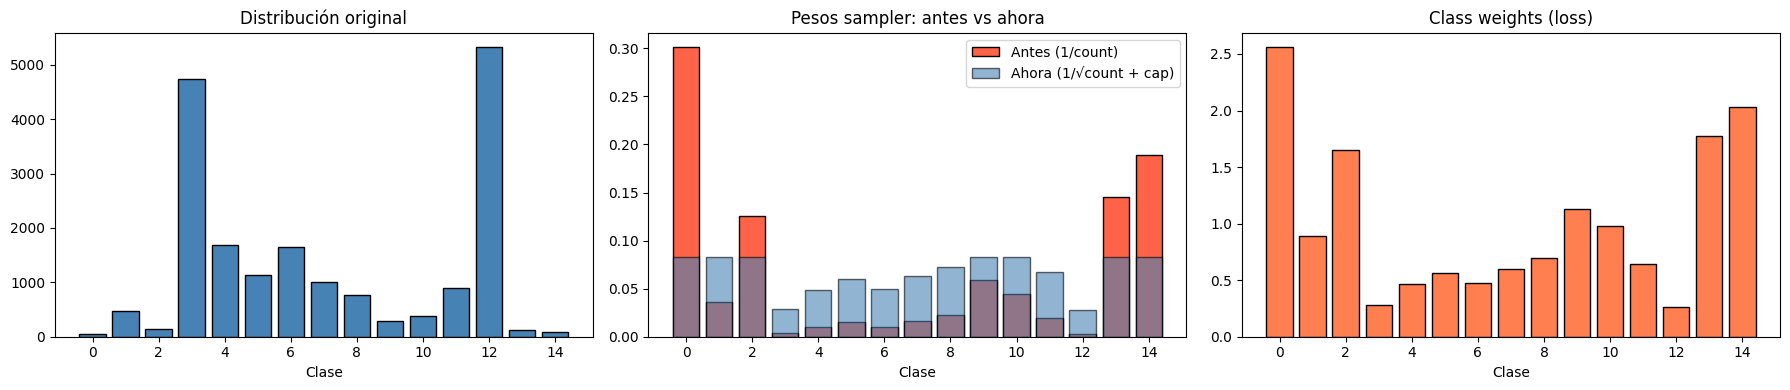

In [7]:
def compute_class_weights(labels, n_classes=15):
    """
    Pesos de clase con suavizado (raíz cuadrada).
    Evita pesos excesivos que sobre-predicen clases raras.
    """
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    counts = np.maximum(counts, 1.0)
    weights = np.sqrt(len(labels) / (n_classes * counts))
    weights = weights / weights.mean()
    return torch.FloatTensor(weights)


def get_sampler(labels, n_classes=15):
    """
    WeightedRandomSampler suavizado con temperatura y cap.

    CORRECCIÓN vs versión anterior:
    El sampler puro (1/count) hacía que la clase 0 (56 muestras) se viera
    ~95 veces más que la clase 12 (5323). Resultado: el modelo memorizaba
    esas 56 muestras → train F1 muy alto pero val F1 bajo.

    Solución:
    - Temperatura √: peso ∝ 1/√count en vez de 1/count → menos agresivo
    - Cap: ninguna clase se sobremuestrea más de 3x la clase más frecuente
    → El modelo ve más variedad y memoriza menos.
    """
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    counts = np.maximum(counts, 1.0)

    # Temperatura √: suaviza el desbalance
    class_weights = 1.0 / np.sqrt(counts)

    # Cap: limitar el oversampling máximo a 3x el peso de la clase mayoritaria
    max_count = counts.max()
    min_allowed_weight = 1.0 / np.sqrt(max_count)  # peso de la clase más frecuente
    class_weights = np.minimum(class_weights, min_allowed_weight * 3.0)

    # Normalizar
    class_weights = class_weights / class_weights.sum() * n_classes

    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(labels),
        replacement=True
    )
    return sampler


# Class weights (sobre originales)
is_aug = train_df['Id'].str.contains('_aug')
original_labels = train_df[~is_aug]['Target'].values
class_weights = compute_class_weights(original_labels, CFG['n_classes'])

print('Pesos de clase (con suavizado √):')
for i, w in enumerate(class_weights):
    count = (original_labels == i).sum()
    print(f'  Clase {i:2d}: {count:5d} muestras → peso = {w:.3f}')

# Visualizar efecto del cap en el sampler
counts_orig = np.bincount(original_labels, minlength=15).astype(float)
weights_old = 1.0 / np.maximum(counts_orig, 1.0)  # versión vieja
weights_new = 1.0 / np.sqrt(np.maximum(counts_orig, 1.0))  # versión nueva √
max_c = counts_orig.max()
cap_val = (1.0 / np.sqrt(max_c)) * 3.0
weights_new_capped = np.minimum(weights_new, cap_val)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(range(15), np.bincount(original_labels, minlength=15), color='steelblue', edgecolor='black')
axes[0].set_title('Distribución original')
axes[0].set_xlabel('Clase')
axes[1].bar(range(15), weights_old / weights_old.sum(), color='tomato', edgecolor='black', label='Antes (1/count)')
axes[1].bar(range(15), weights_new_capped / weights_new_capped.sum(), color='steelblue', edgecolor='black', alpha=0.6, label='Ahora (1/√count + cap)')
axes[1].set_title('Pesos sampler: antes vs ahora')
axes[1].legend()
axes[1].set_xlabel('Clase')
axes[2].bar(range(15), class_weights.numpy(), color='coral', edgecolor='black')
axes[2].set_title('Class weights (loss)')
axes[2].set_xlabel('Clase')
plt.tight_layout()
plt.show()


## 6. Modelo: CNN (EfficientNet-B0) + BiLSTM + Attention Pooling

### Arquitectura detallada:

```
Input: Mel-Spectrograma (3, 128, T)
  ↓
EfficientNet-B0 (pre-entrenado ImageNet)
  → Feature map: (batch, 1280, H', W')
  ↓
Adaptive AvgPool sobre frecuencia → (batch, 1280, W')
  ↓ permute → (batch, W', 1280)
Proyección lineal → (batch, W', 512)
  ↓
BiLSTM (1 capa, hidden=256) → (batch, W', 512)
  ↓
Attention Pooling → (batch, 512)
  ↓
FC(512→256) → ReLU → Dropout(0.4)
FC(256→15) → logits
```

### ¿Por qué Attention Pooling en vez de Global Average Pooling?
- GAP trata todos los frames temporales por igual
- Attention Pooling aprende a ponderar: el estribillo puede ser más informativo que la intro
- Agrega pocos parámetros extra

In [8]:
class AttentionPooling(nn.Module):
    """
    Attention Pooling: aprende a ponderar la importancia de cada
    frame temporal antes de agregar.
    
    En vez de promediar todos los frames (GAP), calcula:
      score_t = tanh(W·h_t + b)
      alpha_t = softmax(v·score_t)
      output = sum(alpha_t * h_t)
    
    Esto permite que el modelo se enfoque en los segmentos más
    discriminativos del clip (ej: el patrón rítmico del drop).
    """
    def __init__(self, dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1)
        )
    

    def freeze_backbone(self):
        """Congela el backbone. Usar en las primeras épocas."""
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        """Descongela el backbone para fine-tuning."""
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        # x: (batch, seq_len, dim)
        weights = self.attention(x)          # (batch, seq_len, 1)
        weights = F.softmax(weights, dim=1)  # normalizar sobre tiempo
        pooled = (x * weights).sum(dim=1)    # (batch, dim)
        return pooled


class AudioClassifier(nn.Module):
    """
    CNN + BiLSTM + Attention para clasificación de audio.
    
    Justificación de cada componente:
    
    1. EfficientNet-B0 (CNN):
       - Extrae patrones locales: texturas tímbricas, patrones rítmicos cortos
       - Pre-entrenado en ImageNet: los filtros de bajo nivel (bordes, texturas)
         se transfieren bien a espectrogramas
       - B0 en vez de B2: ~5M vs ~7M parámetros. Con 18K muestras, menos es más
    
    2. BiLSTM:
       - Captura dependencias temporales: progresión de acordes, cambios de sección
       - Bidireccional: ve el contexto futuro Y pasado
       - 1 capa con 256 hidden: ligero, evita overfitting
    
    3. Attention Pooling:
       - Pondera qué segmentos temporales son más relevantes
       - Más expresivo que GAP para secuencias variables
    """
    
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        
        # ── CNN Backbone ──
        self.backbone = timm.create_model(
            cfg['backbone'],
            pretrained=True,
            num_classes=0,
            global_pool='',
            drop_rate=0.2,
            drop_path_rate=0.1  # Stochastic Depth: regularización adicional
        )
        
        # Detectar dimensión de salida del backbone
        with torch.no_grad():
            dummy = torch.zeros(1, 3, cfg['n_mels'], 862)  # ~20s a 22050Hz/512hop
            feat = self.backbone(dummy)
            self.cnn_channels = feat.shape[1]  # 1280 para EfficientNet-B0
            print(f'CNN output shape: {feat.shape}')
        
        # ── Proyección: reducir dimensión del CNN antes del LSTM ──
        self.proj = nn.Sequential(
            nn.Linear(self.cnn_channels, cfg['lstm_hidden'] * 2),
            nn.LayerNorm(cfg['lstm_hidden'] * 2),
            nn.GELU(),
            nn.Dropout(cfg['dropout'] * 0.5)
        )
        
        # ── BiLSTM temporal ──
        self.lstm = nn.LSTM(
            input_size=cfg['lstm_hidden'] * 2,
            hidden_size=cfg['lstm_hidden'],
            num_layers=cfg['lstm_layers'],
            batch_first=True,
            bidirectional=True,
            dropout=0.0  # 1 sola capa, no necesita dropout entre capas
        )
        
        lstm_out_dim = cfg['lstm_hidden'] * 2  # Bidireccional → 2x
        
        # ── Attention Pooling ──
        self.attention_pool = AttentionPooling(lstm_out_dim)
        
        # ── Classification Head ──
        self.head = nn.Sequential(
            nn.Linear(lstm_out_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(cfg['dropout']),
            nn.Linear(256, cfg['n_classes'])
        )
    

    def freeze_backbone(self):
        """Congela el backbone. Usar en las primeras épocas."""
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        """Descongela el backbone para fine-tuning."""
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        # x: (batch, 3, n_mels, n_frames)
        
        # 1. CNN features
        feat = self.backbone(x)  # (batch, 1280, H', W')
        
        # 2. Pool sobre frecuencia, mantener tiempo
        feat = feat.mean(dim=2)  # (batch, 1280, W') — avg sobre frecuencia
        feat = feat.permute(0, 2, 1)  # (batch, W', 1280) — secuencia temporal
        
        # 3. Proyección
        feat = self.proj(feat)  # (batch, W', 512)
        
        # 4. BiLSTM
        lstm_out, _ = self.lstm(feat)  # (batch, W', 512)
        
        # 5. Attention Pooling
        pooled = self.attention_pool(lstm_out)  # (batch, 512)
        
        # 6. Clasificación
        logits = self.head(pooled)  # (batch, 15)
        
        return logits


# Instanciar y verificar
model = AudioClassifier(CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parámetros entrenables: {n_params:,}')
print(f'  Backbone (EfficientNet-B0): {sum(p.numel() for p in model.backbone.parameters()):,}')
print(f'  Proyección + LSTM + Head: {n_params - sum(p.numel() for p in model.backbone.parameters()):,}')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

CNN output shape: torch.Size([1, 1280, 4, 27])

Total parámetros entrenables: 6,508,684
  Backbone (EfficientNet-B0): 4,007,548
  Proyección + LSTM + Head: 2,501,136


## 7. Focal Loss

### ¿Por qué Focal Loss en vez de CrossEntropy?

CrossEntropy estándar trata todos los ejemplos por igual. Con desbalance 95:1, los ejemplos fáciles de clases mayoritarias dominan el gradiente.

Focal Loss añade un factor modulador $(1-p_t)^\gamma$:
- Si el modelo predice bien (p_t alto) → el factor es ~0 → contribución mínima
- Si el modelo falla (p_t bajo) → el factor es ~1 → contribución completa

Con γ=2: un ejemplo clasificado con 90% de confianza recibe 100x menos peso que uno con 10% de confianza. Esto fuerza al modelo a enfocarse en las muestras difíciles.

In [9]:
class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017) con class weights y label smoothing.
    
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    
    Params:
      gamma: factor de enfoque. 0=CrossEntropy, 2=buen balance (paper original)
      alpha: pesos de clase (tensor de 15 valores)
      label_smoothing: suaviza las etiquetas hard (0/1) → (ε/C, 1-ε+ε/C)
    """
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        if alpha is not None:
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None
    
    def forward(self, logits, targets):
        n_classes = logits.size(1)
        
        # Label smoothing
        if self.label_smoothing > 0:
            with torch.no_grad():
                smooth_targets = torch.zeros_like(logits)
                smooth_targets.fill_(self.label_smoothing / n_classes)
                smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing + self.label_smoothing / n_classes)
        else:
            smooth_targets = F.one_hot(targets, n_classes).float()
        
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        
        # Focal weight: (1 - p_t)^gamma
        focal_weight = (1.0 - probs) ** self.gamma
        
        # Loss por clase
        loss = -focal_weight * smooth_targets * log_probs
        
        # Class weights
        if self.alpha is not None:
            alpha_t = self.alpha.unsqueeze(0)  # (1, n_classes)
            loss = loss * alpha_t
        
        return loss.sum(dim=1).mean()


print('Focal Loss configurada con:')
print(f'  gamma = {CFG["focal_gamma"]} (factor de enfoque)')
print(f'  label_smoothing = {CFG["label_smoothing"]}')
print(f'  class_weights = tensor de {len(class_weights)} valores')

Focal Loss configurada con:
  gamma = 2.0 (factor de enfoque)
  label_smoothing = 0.1
  class_weights = tensor de 15 valores


## 8. Mixup: regularización por interpolación

Mixup (Zhang et al., 2018) crea muestras sintéticas interpolando pares:
- `x_mix = λ·x_i + (1-λ)·x_j`
- `y_mix = λ·y_i + (1-λ)·y_j`

Fuerza al modelo a aprender transiciones suaves entre clases → mejor generalización.

In [10]:
def mixup_data(x, y, alpha=0.3):
    """Mixup augmentation."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, logits, y_a, y_b, lam):
    """Loss para datos con mixup."""
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

## 9. Preparación de datos: Stratified K-Fold + DataLoaders

In [11]:
# =================================================================
# STRATIFIED K-FOLD
# =================================================================
# Decisión: el split se hace SOLO sobre las filas originales
# (sin las copias augmentadas). Las copias augmentadas de clases
# minoritarias siempre van a train, nunca a validación.

# Separar originales de augmentadas
is_augmented = train_df['Id'].str.contains('_aug')
train_original = train_df[~is_augmented].copy().reset_index(drop=True)
train_augmented = train_df[is_augmented].copy().reset_index(drop=True)

print(f'Originales: {len(train_original)} | Augmentadas: {len(train_augmented)}')

skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])

train_original['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(train_original, train_original['Target'])):
    train_original.loc[val_idx, 'fold'] = fold_idx

# Seleccionar fold
fold = CFG['fold']
train_fold_orig = train_original[train_original['fold'] != fold].reset_index(drop=True)
val_fold_df = train_original[train_original['fold'] == fold].reset_index(drop=True)

# Agregar augmentadas al train (nunca al validation)
# Solo las augmentadas cuyos originales están en train_fold
train_orig_ids = set(train_fold_orig['Id'])
aug_for_fold = train_augmented[
    train_augmented['Id'].apply(lambda x: x.rsplit('_aug', 1)[0]).isin(train_orig_ids)
].reset_index(drop=True)

train_fold_df = pd.concat([train_fold_orig, aug_for_fold], ignore_index=True)

print(f'\nFold {fold}:')
print(f'  Train: {len(train_fold_df)} ({len(train_fold_orig)} orig + {len(aug_for_fold)} aug)')
print(f'  Val:   {len(val_fold_df)} (solo originales)')

# Datasets
train_dataset = MusicGenreDataset(train_fold_df, CFG, is_train=True)
val_dataset = MusicGenreDataset(val_fold_df, CFG, is_train=False)
test_dataset = MusicGenreDataset(test_df, CFG, is_train=False)

# WeightedRandomSampler
train_sampler = get_sampler(train_fold_df['Target'].values, CFG['n_classes'])

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['batch_size'],
    sampler=train_sampler,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory'],
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

print(f'\nTrain batches: {len(train_loader)} (con WeightedRandomSampler)')
print(f'Val batches:   {len(val_loader)}')

Originales: 18719 | Augmentadas: 2049

Fold 0:
  Train: 16616 (14975 orig + 1641 aug)
  Val:   3744 (solo originales)

Train batches: 519 (con WeightedRandomSampler)
Val batches:   59


## 10. Optimizador y Scheduler

### Decisiones:
- **AdamW** con weight decay 1e-3 (más L2 que antes)
- **Learning rate diferencial**: backbone CNN aprende 10x más lento que la cabeza nueva
  - El backbone ya tiene buenos filtros de ImageNet → ajuste fino sutil
  - La cabeza (LSTM + classifier) se entrena desde cero → necesita LR mayor
- **OneCycleLR**: empieza con LR bajo, sube al máximo, y baja gradualmente
  - Converge más rápido que CosineAnnealing puro
  - Incluye warmup automático

In [12]:
# =================================================================
# OPTIMIZADOR — se reconfigura al descongelar backbone
# =================================================================

def build_optimizer_and_scheduler(model, cfg, train_loader, backbone_frozen=True):
    """
    Construye optimizer y scheduler según si el backbone está congelado.

    Fase 1 (backbone_frozen=True, épocas 1-freeze_epochs):
      Solo entrena cabeza con lr alto → converge rápido y estable.
      El backbone conserva sus pesos de ImageNet sin distorsionarse.

    Fase 2 (backbone_frozen=False, épocas freeze_epochs+1 en adelante):
      LR diferencial: backbone lr×0.01 (muy suave), cabeza lr×0.1.
      Ajuste fino sin destruir los features pre-entrenados.
    """
    head_params = (
        list(model.proj.parameters()) +
        list(model.lstm.parameters()) +
        list(model.attention_pool.parameters()) +
        list(model.head.parameters())
    )

    if backbone_frozen:
        # Solo cabeza
        param_groups = [{'params': head_params, 'lr': cfg['lr']}]
        max_lrs = [cfg['lr']]
    else:
        # Backbone (lr muy pequeño) + cabeza
        backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
        param_groups = [
            {'params': backbone_params, 'lr': cfg['lr'] * 0.01},
            {'params': head_params,     'lr': cfg['lr'] * 0.1},
        ]
        max_lrs = [cfg['lr'] * 0.01, cfg['lr'] * 0.1]

    optimizer = AdamW(param_groups, weight_decay=cfg['weight_decay'])

    remaining_epochs = cfg['epochs'] - (cfg['freeze_epochs'] if not backbone_frozen else 0)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=max_lrs,
        epochs=remaining_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        anneal_strategy='cos',
        div_factor=25,
        final_div_factor=1000
    )
    return optimizer, scheduler


# Iniciar con backbone congelado
model.freeze_backbone()
optimizer, scheduler = build_optimizer_and_scheduler(
    model, CFG, train_loader, backbone_frozen=True
)

criterion = FocalLoss(
    gamma=CFG['focal_gamma'],
    alpha=class_weights.to(DEVICE),
    label_smoothing=CFG['label_smoothing']
)
scaler = GradScaler(enabled=CFG['fp16'])

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Backbone: CONGELADO por {CFG["freeze_epochs"]} épocas')
print(f'Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
print(f'LR cabeza: {CFG["lr"]}')
print(f'Fase 2 (epoch {CFG["freeze_epochs"]+1}+): backbone lr={CFG["lr"]*0.01}, cabeza lr={CFG["lr"]*0.1}')


Backbone: CONGELADO por 5 épocas
Parámetros entrenables: 2,501,136 / 6,508,684 (38.4%)
LR cabeza: 0.001
Fase 2 (epoch 6+): backbone lr=1e-05, cabeza lr=0.0001


## 11. Funciones de entrenamiento y validación

In [13]:
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler, device, cfg):
    """Un epoch de entrenamiento.

    CORRECCIÓN vs versión anterior:
    Ahora el train F1 se calcula sobre TODOS los batches (con y sin mixup).
    Antes solo se acumulaban los batches sin mixup (~50%), lo que daba un
    F1 artificialmente alto y hacía el gap train/val parecer mayor.
    """
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        use_mixup = cfg['use_mixup'] and np.random.random() < 0.5
        if use_mixup:
            inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, cfg['mixup_alpha'])

        optimizer.zero_grad()

        with autocast(enabled=cfg['fp16']):
            logits = model(inputs)
            if use_mixup:
                loss = mixup_criterion(criterion, logits, labels_a, labels_b, lam)
            else:
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

        # F1 honesto: siempre acumular predicciones (argmax sobre logits)
        # Para batches con mixup usamos la etiqueta dominante (lam >= 0.5 → labels_a)
        with torch.no_grad():
            preds = logits.argmax(dim=1).cpu().numpy()
            if use_mixup:
                true = labels_a.cpu().numpy() if lam >= 0.5 else labels_b.cpu().numpy()
            else:
                true = labels.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(true)

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1


@torch.no_grad()
def val_epoch(model, loader, criterion, device, cfg):
    """Un epoch de validación."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    all_probs = []

    for inputs, labels in tqdm(loader, desc='Validation', leave=False):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=cfg['fp16']):
            logits = model(inputs)
            loss = criterion(logits, labels)

        total_loss += loss.item()
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.append(probs)

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    all_probs = np.vstack(all_probs)
    return avg_loss, macro_f1, all_preds, all_labels, all_probs


print('Funciones de entrenamiento definidas.')


Funciones de entrenamiento definidas.


## 12. Entrenamiento principal con Early Stopping

In [14]:
# =================================================================
# ENTRENAMIENTO CON FREEZE → UNFREEZE
# =================================================================

best_f1 = 0.0
best_epoch = 0
patience = 10
patience_counter = 0
backbone_unfrozen = False

history = {
    'train_loss': [], 'train_f1': [],
    'val_loss': [], 'val_f1': [],
    'lr': []
}

save_path = f'best_model_fold{fold}.pth'

print('=' * 70)
print(f'Entrenamiento — Fold {fold}')
print(f'Fase 1 (épocas 1-{CFG["freeze_epochs"]}): backbone CONGELADO, solo entrena cabeza')
print(f'Fase 2 (épocas {CFG["freeze_epochs"]+1}+): backbone DESCONGELADO con lr×0.01')
print(f'Sampler: 1/√count con cap 3x (antes: 1/count sin cap)')
print(f'Train F1: calculado sobre TODOS los batches (antes: solo sin-mixup)')
print('=' * 70)

for epoch in range(1, CFG['epochs'] + 1):

    # ── Transición Fase 1 → Fase 2 ──
    if epoch == CFG['freeze_epochs'] + 1 and not backbone_unfrozen:
        print(f'\n>>> Epoch {epoch}: DESCONGELANDO backbone (lr×0.01) <<<')
        model.unfreeze_backbone()
        optimizer, scheduler = build_optimizer_and_scheduler(
            model, CFG, train_loader, backbone_frozen=False
        )
        backbone_unfrozen = True
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'    Parámetros entrenables: {trainable:,}')
        print(f'    Backbone LR: {CFG["lr"]*0.01} | Head LR: {CFG["lr"]*0.1}\n')

    current_lr = optimizer.param_groups[-1]['lr']  # LR del último grupo (cabeza)

    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, scaler, DEVICE, CFG
    )
    val_loss, val_f1, val_preds, val_labels, val_probs = val_epoch(
        model, val_loader, criterion, DEVICE, CFG
    )

    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    improved = val_f1 > best_f1
    if improved:
        best_f1 = val_f1
        best_epoch = epoch
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'best_f1': best_f1,
            'cfg': CFG
        }, save_path)
    else:
        patience_counter += 1

    phase = 'FROZEN' if epoch <= CFG['freeze_epochs'] else 'FINETUNE'
    status = '✓ BEST' if improved else f'(patience {patience_counter}/{patience})'
    gap = train_f1 - val_f1
    print(
        f'[{phase}] Epoch {epoch:2d}/{CFG["epochs"]} | '
        f'Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | '
        f'Gap: {gap:+.4f} | LR: {current_lr:.2e} | {status}'
    )

    # Early stopping solo en Fase 2
    if backbone_unfrozen and patience_counter >= patience:
        print(f'\nEarly stopping en epoch {epoch}. Mejor F1: {best_f1:.4f} (epoch {best_epoch})')
        break

print(f'\nEntrenamiento completo. Mejor Macro F1 en val: {best_f1:.4f} (epoch {best_epoch})')


Entrenamiento — Fold 0
Fase 1 (épocas 1-5): backbone CONGELADO, solo entrena cabeza
Fase 2 (épocas 6+): backbone DESCONGELADO con lr×0.01
Sampler: 1/√count con cap 3x (antes: 1/count sin cap)
Train F1: calculado sobre TODOS los batches (antes: solo sin-mixup)


Training:   0%|          | 0/519 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

[FROZEN] Epoch  1/40 | Train F1: 0.2528 | Val F1: 0.2847 | Gap: -0.0319 | LR: 4.00e-05 | ✓ BEST


Training:   0%|          | 0/519 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

[FINETUNE] Epoch 39/40 | Train F1: 0.7383 | Val F1: 0.5200 | Gap: +0.2183 | LR: 9.93e-07 | (patience 5/10)


Training:   0%|          | 0/519 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

[FINETUNE] Epoch 40/40 | Train F1: 0.7475 | Val F1: 0.5242 | Gap: +0.2232 | LR: 2.51e-07 | (patience 6/10)

Entrenamiento completo. Mejor Macro F1 en val: 0.5270 (epoch 34)


## 13. Visualización de resultados de entrenamiento

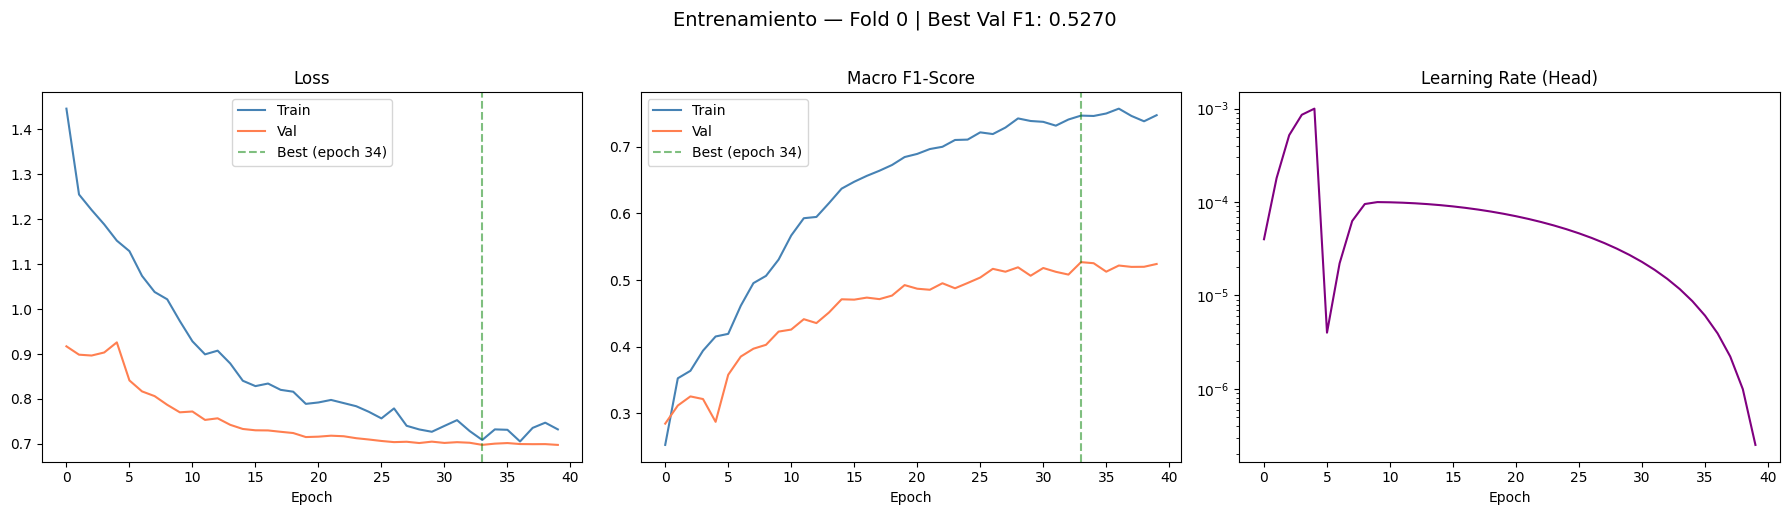

In [15]:
# =================================================================
# CURVAS DE ENTRENAMIENTO
# =================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'], label='Val', color='coral')
axes[0].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# F1
axes[1].plot(history['train_f1'], label='Train', color='steelblue')
axes[1].plot(history['val_f1'], label='Val', color='coral')
axes[1].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[1].set_title('Macro F1-Score')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# LR
axes[2].plot(history['lr'], color='purple')
axes[2].set_title('Learning Rate (Head)')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')

plt.suptitle(f'Entrenamiento — Fold {fold} | Best Val F1: {best_f1:.4f}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Evaluación detallada del mejor modelo

Mejor modelo cargado (epoch 34, F1=0.5270)


Validation:   0%|          | 0/59 [00:00<?, ?it/s]


Macro F1-Score en validación: 0.5270

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.09      0.09      0.09        11
           1       0.68      0.89      0.77        93
           2       0.28      0.63      0.39        27
           3       0.77      0.66      0.71       947
           4       0.44      0.45      0.44       338
           5       0.57      0.61      0.59       228
           6       0.65      0.78      0.71       329
           7       0.38      0.46      0.41       202
           8       0.54      0.70      0.61       153
           9       0.34      0.56      0.42        57
          10       0.99      0.97      0.98        76
          11       0.19      0.29      0.23       178
          12       0.89      0.65      0.75      1064
          13       0.22      0.57      0.32        23
          14       0.36      0.67      0.47        18

    accuracy                           0.63      3744
   macro avg   

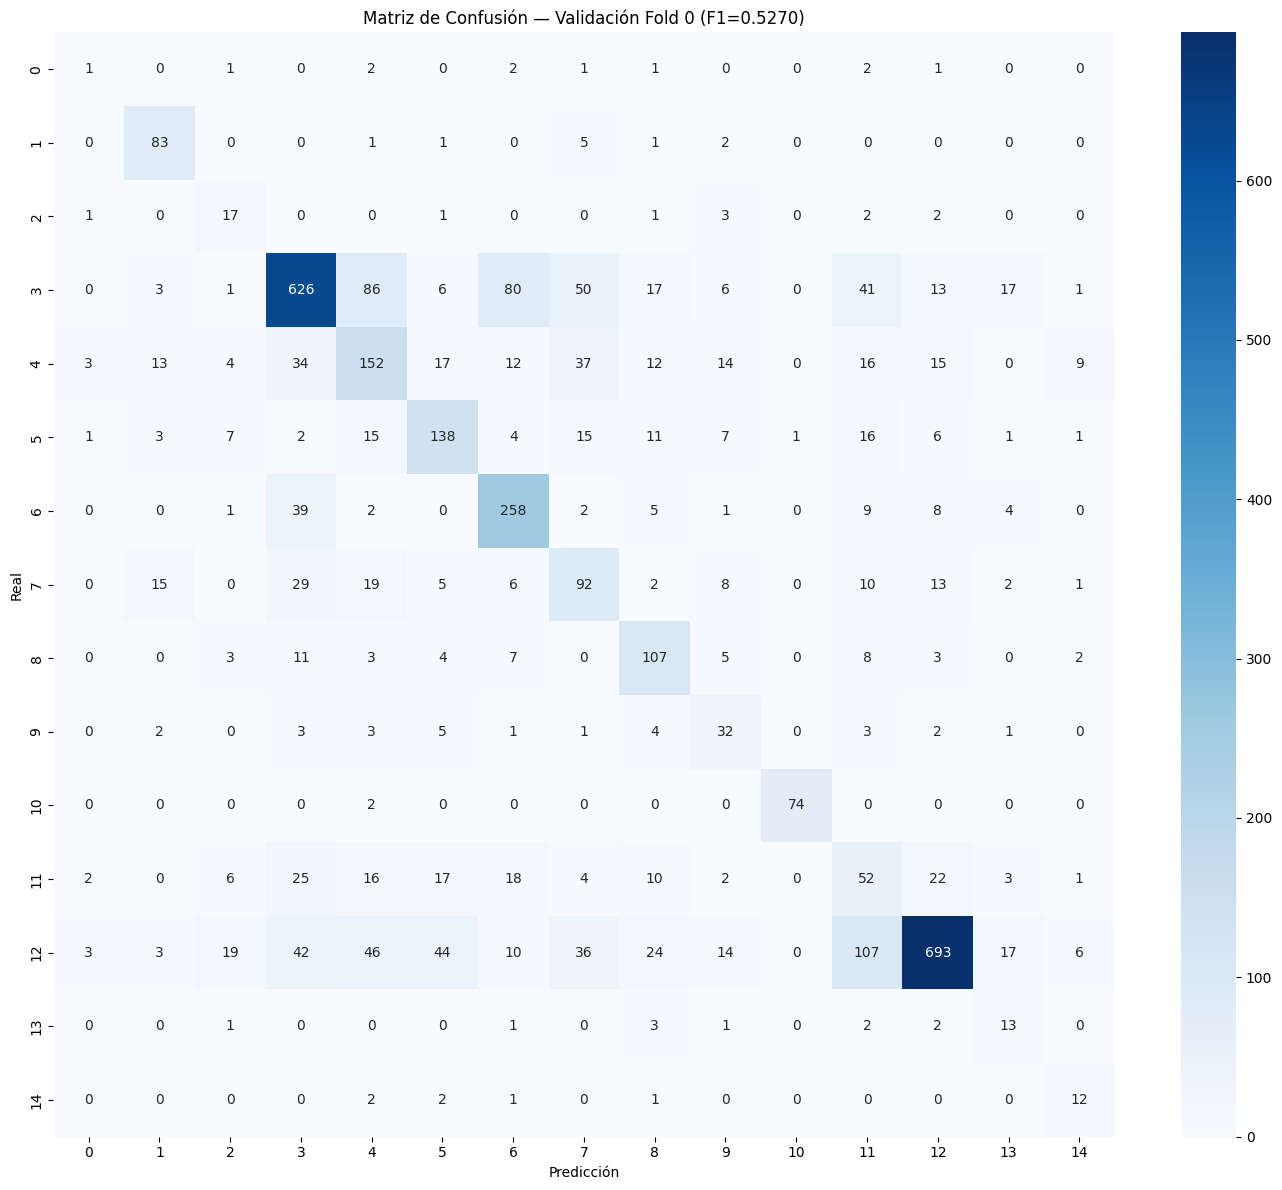

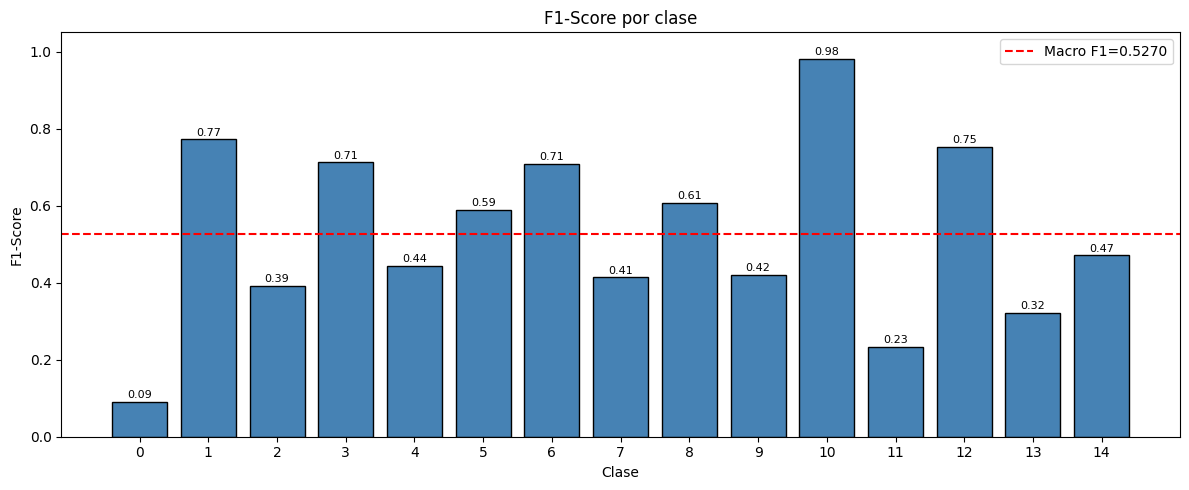

In [16]:
# Cargar mejor modelo
checkpoint = torch.load(save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Mejor modelo cargado (epoch {checkpoint["epoch"]}, F1={checkpoint["best_f1"]:.4f})')

# Evaluación final
_, final_f1, final_preds, final_labels, _ = val_epoch(
    model, val_loader, criterion, DEVICE, CFG
)

print(f'\nMacro F1-Score en validación: {final_f1:.4f}')
print('\nReporte de clasificación:')
print(classification_report(final_labels, final_preds, zero_division=0))

# Diagnóstico: distribución de predicciones vs real
print('\nDistribución predicciones vs real:')
pred_counts = Counter(final_preds)
for cls in range(15):
    real = (np.array(final_labels) == cls).sum()
    pred = pred_counts.get(cls, 0)
    print(f'  Clase {cls:2d}: real={real:4d} | pred={pred:4d}')

# Matriz de confusión
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(15), yticklabels=range(15))
plt.title(f'Matriz de Confusión — Validación Fold {fold} (F1={final_f1:.4f})')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# F1 por clase
f1_per_class = f1_score(final_labels, final_preds, average=None, zero_division=0)
plt.figure(figsize=(12, 5))
bars = plt.bar(range(15), f1_per_class, color='steelblue', edgecolor='black')
plt.axhline(final_f1, color='red', linestyle='--', label=f'Macro F1={final_f1:.4f}')
plt.xlabel('Clase')
plt.ylabel('F1-Score')
plt.title('F1-Score por clase')
plt.xticks(range(15))
plt.ylim(0, 1.05)
plt.legend()
for bar, f1_val in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, f1_val + 0.01, f'{f1_val:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 15. Predicción con Test Time Augmentation (TTA)

TTA promedia las probabilidades de múltiples pasadas con diferentes augmentaciones.
Reduce la varianza y típicamente mejora el F1 en 1-3 puntos.

In [17]:
@torch.no_grad()
def predict_with_tta(model, dataset, device, cfg, n_tta=5):
    """
    Test Time Augmentation.
    Pasada 0: sin augmentation (predicción limpia)
    Pasadas 1-4: con SpecAugment → promedia probabilidades
    """
    model.eval()
    all_probs = []
    
    for tta_idx in range(n_tta):
        dataset.is_train = (tta_idx > 0)  # Activar SpecAugment solo en pasadas > 0
        
        loader = DataLoader(
            dataset,
            batch_size=cfg['batch_size'] * 2,
            shuffle=False,
            num_workers=cfg['num_workers'],
            pin_memory=cfg['pin_memory']
        )
        
        tta_probs = []
        for batch in tqdm(loader, desc=f'TTA {tta_idx+1}/{n_tta}', leave=False):
            if isinstance(batch, (list, tuple)):
                inputs = batch[0].to(device, non_blocking=True)
            else:
                inputs = batch.to(device, non_blocking=True)
            
            with autocast(enabled=cfg['fp16']):
                logits = model(inputs)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            tta_probs.append(probs)
        
        all_probs.append(np.vstack(tta_probs))
    
    dataset.is_train = False  # Restaurar
    
    # Promedio de probabilidades
    mean_probs = np.mean(all_probs, axis=0)
    predictions = np.argmax(mean_probs, axis=1)
    
    return predictions, mean_probs


print('Generando predicciones con TTA (5 pasadas)...')
test_preds, test_probs = predict_with_tta(model, test_dataset, DEVICE, CFG, n_tta=5)

print(f'\nPredicciones: {len(test_preds)}')
print('Distribución:')
pred_dist = Counter(test_preds)
for cls in sorted(pred_dist.keys()):
    print(f'  Clase {cls:2d}: {pred_dist[cls]:5d}')

Generando predicciones con TTA (5 pasadas)...


TTA 1/5:   0%|          | 0/98 [00:00<?, ?it/s]

TTA 2/5:   0%|          | 0/98 [00:00<?, ?it/s]

TTA 3/5:   0%|          | 0/98 [00:00<?, ?it/s]

TTA 4/5:   0%|          | 0/98 [00:00<?, ?it/s]

TTA 5/5:   0%|          | 0/98 [00:00<?, ?it/s]


Predicciones: 6240
Distribución:
  Clase  0:    13
  Clase  1:   191
  Clase  2:   113
  Clase  3:  1298
  Clase  4:   630
  Clase  5:   403
  Clase  6:   663
  Clase  7:   477
  Clase  8:   311
  Clase  9:   157
  Clase 10:   129
  Clase 11:   442
  Clase 12:  1277
  Clase 13:    70
  Clase 14:    66


## 16. Generar archivo de submission

In [18]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'Target': test_preds
})

submission.to_csv('submission.csv', index=False)

print(f'Submission generada: {len(submission)} filas')
print(submission.head(10))

# Verificaciones
assert len(submission) == len(test_df), 'ERROR: número de predicciones no coincide'
assert submission['Target'].between(0, 14).all(), 'ERROR: predicciones fuera de [0, 14]'
assert not submission.isnull().any().any(), 'ERROR: valores nulos'
print('\n✓ Formato verificado correctamente')

Submission generada: 6240 filas
                 Id  Target
0  000ad3f474c22732       4
1  000c01fb027c9720      12
2  0011f18cdfde1eb2       8
3  002c8a7c75197a78      12
4  0034afa0ffefe542      10
5  00360bf471794cde      12
6  003fd6961434c5a8      12
7  0045bb6d5fdfe02c       3
8  004e91ea1bc30ed6       9
9  0050ea62569bbbe5       3

✓ Formato verificado correctamente


# Submit Kaggle

In [22]:
#!kaggle competitions submit -c music-genres-2026-i -f submission.csv  -m "Version 2"

100%|█████████████████████████████████████████| 118k/118k [00:00<00:00, 285kB/s]
Successfully submitted to Music genres

In [20]:
from IPython.display import FileLink

# Escribe el nombre exacto de tu archivo
FileLink('submission.csv')

/kaggle/working/submission.csv

## 17. (Opcional) Ensemble de múltiples folds

Para máximo rendimiento, entrena los 5 folds y promedia sus predicciones.
El ensemble reduce la varianza y típicamente mejora el F1 en 2-4 puntos.

In [21]:
USE_ENSEMBLE = False  # Cambiar a True después de entrenar todos los folds

if USE_ENSEMBLE:
    all_fold_probs = []
    
    for fold_idx in range(CFG['n_folds']):
        fold_path = f'best_model_fold{fold_idx}.pth'
        if not os.path.exists(fold_path):
            print(f'Fold {fold_idx} no encontrado, saltando...')
            continue
        
        print(f'Cargando fold {fold_idx}...')
        fold_model = AudioClassifier(CFG).to(DEVICE)
        ckpt = torch.load(fold_path, map_location=DEVICE)
        fold_model.load_state_dict(ckpt['model_state_dict'])
        
        _, probs = predict_with_tta(fold_model, test_dataset, DEVICE, CFG, n_tta=3)
        all_fold_probs.append(probs)
        print(f'  F1 validación: {ckpt["best_f1"]:.4f}')
        del fold_model
        torch.cuda.empty_cache()
    
    if all_fold_probs:
        ensemble_probs = np.mean(all_fold_probs, axis=0)
        ensemble_preds = np.argmax(ensemble_probs, axis=1)
        
        ensemble_sub = pd.DataFrame({'Id': test_df['Id'], 'Target': ensemble_preds})
        ensemble_sub.to_csv('submission_ensemble.csv', index=False)
        print(f'\nEnsemble de {len(all_fold_probs)} folds → submission_ensemble.csv')
else:
    print('Ensemble desactivado. Usa submission.csv del fold único.')
    print('Para ensemble: entrena todos los folds cambiando CFG["fold"] = 0,1,2,3,4')

Ensemble desactivado. Usa submission.csv del fold único.
Para ensemble: entrena todos los folds cambiando CFG["fold"] = 0,1,2,3,4


## Resumen de estrategias anti-overfitting

| Estrategia | Tipo | Efecto |
|---|---|---|
| **EfficientNet-B0** (no B2) | Arquitectura | Menos parámetros → menos capacidad de memorizar |
| **BiLSTM 1 capa** (no Transformer 4 capas) | Arquitectura | 10x menos parámetros temporales |
| **Dropout 0.4** | Regularización | Desactiva 40% de neuronas al azar |
| **Weight Decay 1e-3** | Regularización L2 | Penaliza pesos grandes |
| **SpecAugment** | Data Augmentation | Máscaras aleatorias en espectrograma |
| **Audio Augmentation** | Data Augmentation | Ruido, pitch shift, time stretch |
| **Mixup (α=0.3)** | Data Augmentation | Interpolación de muestras |
| **Label Smoothing 0.1** | Regularización | Evita sobreconfianza |
| **Early Stopping** (patience=10) | Entrenamiento | Detiene antes del overfitting |
| **OneCycleLR** | Entrenamiento | Warmup + decay previene aprendizaje inestable |
| **Focal Loss** | Loss function | Enfoca en muestras difíciles |
| **Class Weights** | Desbalance | Equilibra gradientes entre clases |
| **WeightedRandomSampler** | Desbalance | Muestra balanceado por epoch |
| **LR diferencial** | Transfer Learning | Backbone se ajusta suavemente |
| **Gradient Clipping** | Estabilidad | Previene explosión de gradientes en LSTM |